# Scikit-learn Baseline Model

This notebook reproduces a traditional machine learning baseline for the binary diabetes risk prediction task.

The goal is to establish a reliable comparison point for the PyTorch models developed later in this project.

The baseline uses a scikit-learn preprocessing pipeline and a balanced Random Forest classifier, with evaluation focused on recall, ROC-AUC, threshold sensitivity, and class imbalance-aware performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## Load Dataset

The dataset is loaded from the local `data/` directory.

The original target variable, `Diabetes_012`, contains three classes:

- 0: No diabetes
- 1: Prediabetes
- 2: Diabetes

Following the previous project, the target is converted into a binary clinical risk prediction task:

- 0: No diabetes
- 1: At risk, including prediabetes or diabetes

In [2]:
DATA_PATH = Path("../data/diabetes_012_health_indicators_BRFSS2015.csv")

def load_diabetes_data(data_path=DATA_PATH):
    if not DATA_PATH.is_file():
        raise FileNotFoundError(
            f"Dataset not found at {data_path}."
            "Please place the BRFSS 2015 diabetes csv file in the data/ directory."
        )
    return pd.read_csv(data_path)

df = load_diabetes_data()

print(df.shape)
print(df.head())

(253680, 22)
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        

In [3]:
# Convert the original 3-class target into a binary clinical risk label
df["Diabetes_binary"] = (df["Diabetes_012"] > 0).astype(int)

target_distribution = df["Diabetes_binary"].value_counts(normalize=True).sort_index()

target_distribution

Diabetes_binary
0    0.842412
1    0.157588
Name: proportion, dtype: float64

## Train/Test Split

A stratified train/test split is used to preserve the proportion of non-risk and at-risk individuals in both sets.

This is important because the scikit-learn baseline and PyTorch models should be evaluated under the same class distribution. Keeping the test set consistent makes future model comparisons more fair.

Although the binary target and stratified split were introduced in the data understanding notebook, they are recreated here so that this baseline notebook can run independently and provide a reproducible training pipeline.

In [4]:
X = df.drop(columns=["Diabetes_012", "Diabetes_binary"])
y = df["Diabetes_binary"]

# Use stratification to preserve the at-risk class proportion in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (202944, 21)
X_test: (50736, 21)


In [5]:
split_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
})

split_distribution

,train,test
Diabetes_binary,,
0,0.84241,0.84242
1,0.15759,0.15758


## Preprocessing Pipeline

The preprocessing pipeline follows the previous scikit-learn project:

- `BMI` is log-transformed and standardized because it is a skewed numerical feature.
- Ordinal and continuous features are standardized.
- Binary features are passed through without scaling.

The transformations are wrapped in a scikit-learn `ColumnTransformer` to reduce data leakage risk and keep preprocessing consistent between training and evaluation.

In [6]:
skewed_features = ["BMI"]

num_ord_features = [
    "GenHlth", "MentHlth", "PhysHlth",
    "Age", "Education", "Income"
]

binary_features = [
    "HighBP", "HighChol", "CholCheck",
    "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex"
]

all_features = skewed_features + num_ord_features + binary_features

print("Number of selected features:", len(all_features))

Number of selected features: 21


In [7]:
# Apply log transformation only to BMI, which is a skewed numerical feature
preprocessor = ColumnTransformer(
    transformers=[
        (
            "skewed", Pipeline([
                ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                ("scaler", StandardScaler())
            ]),
            skewed_features
        ),
        (
            "num_ord",
            StandardScaler(),
            num_ord_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

## Random Forest Baseline

A Random Forest model is used as the main traditional machine learning baseline.

The model is wrapped in a scikit-learn `Pipeline` so that preprocessing and model training are performed together. This helps prevent data leakage and ensures that the same transformations are applied consistently during training and evaluation.

Class weighting is used to reduce the effect of class imbalance by assigning higher penalty to mistakes on the minority class.

In [8]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced", # Penalize minority-class mistakes more heavily
        random_state=42,
        n_jobs=-1
    ))
])

## Hyperparameter Tuning with RandomizedSearchCV

To create a stronger traditional machine learning baseline, `RandomizedSearchCV` is used to tune the Random Forest hyperparameters.

The search space follows the previous scikit-learn deployment project to keep the baseline consistent with the earlier work.

ROC-AUC is used as the optimization metric because the task is imbalanced and probability ranking is more informative than raw accuracy for later threshold tuning.

In [9]:
param_dist = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [10, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf_pipeline = random_search.best_estimator_

print("Best CV ROC-AUC:", random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

Best CV ROC-AUC: 0.8190753243236997
Best parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': 15}


## Cross-Validated Training Evaluation at Default Threshold

Before evaluating on the held-out test set, cross-validated predictions are generated from the training set.

This allows the baseline model to be evaluated at the default threshold of 0.5 without touching the test set.

The same cross-validated probabilities will also be used for threshold tuning.

In [10]:
def evaluate_predictions(y_true, y_pred, y_proba):
    """
    Return core classification metrics for binary risk prediction.
    
    ROC-AUC uses predicted probabilities, while the other metrics use
    thresholded class predictions.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

    return {metric: round(score, 4) for metric, score in metrics.items()}

In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate out-of-fold probabilities from the training set only.
# These predictions are used for threshold analysis without touching the test set.
y_proba_train_cv = cross_val_predict(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Default classification threshold
y_pred_train_cv_default = (y_proba_train_cv >= 0.5).astype(int)

In [12]:
metrics_cv_default = evaluate_predictions(
    y_true=y_train,
    y_pred=y_pred_train_cv_default,
    y_proba=y_proba_train_cv
)

metrics_cv_default

{'Accuracy': 0.766,
 'Precision': 0.3694,
 'Recall': 0.6853,
 'F1': 0.48,
 'ROC-AUC': 0.8192}

In [13]:
print(classification_report(y_train, y_pred_train_cv_default))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85    170962
           1       0.37      0.69      0.48     31982

    accuracy                           0.77    202944
   macro avg       0.65      0.73      0.66    202944
weighted avg       0.84      0.77      0.79    202944



In [14]:
confusion_matrix(y_train, y_pred_train_cv_default)

array([[133540,  37422],
       [ 10065,  21917]])

At the default threshold of 0.5, the tuned Random Forest identifies a meaningful proportion of at-risk individuals while maintaining reasonable overall performance.

However, the results also show the expected trade-off in an imbalanced preventative screening task: improving recall for the at-risk class comes with lower precision and more false positives.

Because this project prioritizes identifying at-risk individuals, threshold tuning is explored next to better align the final decision rule with the clinical screening objective.

## Threshold Tuning with Cross-Validated Training Predictions

The default threshold of 0.5 may not be optimal for a preventative clinical screening task.

At the default threshold, the tuned Random Forest captures many at-risk individuals, but the decision rule can still be adjusted to better reflect the clinical screening objective.

To avoid tuning the threshold directly on the test set, the threshold is selected using only cross-validated predicted probabilities from the training set.

Youden's J statistic is used as an interpretable threshold selection criterion. It selects the threshold that maximizes the difference between the true positive rate and the false positive rate:

$$J = \text{True Positive Rate} - \text{False Positive Rate}$$

This is useful in a screening context because it improves sensitivity while still penalizing excessive false positives, rather than maximizing recall alone.

The selected threshold is then applied once to the held-out test set for final evaluation.

In [15]:
fpr, tpr, thresholds = roc_curve(y_train, y_proba_train_cv)

# Youden's J selects the threshold where TPR exceeds FPR by the largest margin.
# This improves sensitivity while penalizing excessive false positives.
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print(round(best_threshold, 3))

0.399


In [16]:
# Apply the CV-selected threshold to the cross-validated training probabilities
y_pred_train_cv_tuned = (y_proba_train_cv >= best_threshold).astype(int)

metrics_cv_tuned = evaluate_predictions(
    y_true=y_train,
    y_pred=y_pred_train_cv_tuned,
    y_proba=y_proba_train_cv
)

metrics_cv_tuned

{'Accuracy': 0.7008,
 'Precision': 0.321,
 'Recall': 0.8063,
 'F1': 0.4592,
 'ROC-AUC': 0.8192}

In [17]:
metrics_cv_comparison = pd.DataFrame({
    "CV Default Threshold": metrics_cv_default,
    "CV Tuned Threshold": metrics_cv_tuned
})

metrics_cv_comparison

,CV Default Threshold,CV Tuned Threshold
Accuracy,0.7660,0.7008
Precision,0.3694,0.3210
Recall,0.6853,0.8063
F1,0.4800,0.4592
ROC-AUC,0.8192,0.8192


In [18]:
print(classification_report(y_train, y_pred_train_cv_tuned))

              precision    recall  f1-score   support

           0       0.95      0.68      0.79    170962
           1       0.32      0.81      0.46     31982

    accuracy                           0.70    202944
   macro avg       0.64      0.74      0.63    202944
weighted avg       0.85      0.70      0.74    202944



In [19]:
confusion_matrix(y_train, y_pred_train_cv_tuned)

array([[116426,  54536],
       [  6194,  25788]])

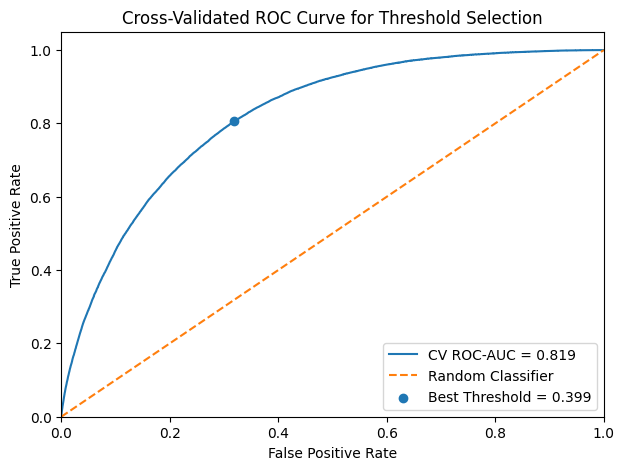

In [20]:
roc_auc_train_cv = roc_auc_score(y_train, y_proba_train_cv)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"CV ROC-AUC = {roc_auc_train_cv:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.scatter(
    fpr[best_idx],
    tpr[best_idx],
    label=f"Best Threshold = {best_threshold:.3f}"
)

plt.axis([0, 1, 0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curve for Threshold Selection")
plt.legend()
plt.show()

## Final Test Evaluation with Tuned Threshold

After selecting the classification threshold using only cross-validated training predictions, the tuned Random Forest model is evaluated on the held-out test set.

The test set is used only for final evaluation. It is not used for hyperparameter tuning or threshold selection.

This provides a more realistic estimate of baseline performance before comparing the scikit-learn model against PyTorch models.

In [21]:
# Predict probabilities on the held-out test set only after model and threshold selection are complete
y_proba_test = best_rf_pipeline.predict_proba(X_test)[:, 1]

# Compare the standard 0.5 threshold with the CV-selected tuned threshold
y_pred_test_default = (y_proba_test >= 0.5).astype(int)
y_pred_test_tuned = (y_proba_test >= best_threshold).astype(int)

In [22]:
metrics_test_default = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_test_default,
    y_proba=y_proba_test
)

metrics_test_tuned = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_test_tuned,
    y_proba=y_proba_test
)

metrics_test_comparison = pd.DataFrame({
    "Test Default Threshold": metrics_test_default,
    "Test Tuned Threshold": metrics_test_tuned
})

metrics_test_comparison

,Test Default Threshold,Test Tuned Threshold
Accuracy,0.7624,0.6956
Precision,0.3664,0.3168
Recall,0.6962,0.8058
F1,0.4801,0.4548
ROC-AUC,0.8186,0.8186


In [23]:
print(classification_report(y_test, y_pred_test_tuned))

              precision    recall  f1-score   support

           0       0.95      0.67      0.79     42741
           1       0.32      0.81      0.45      7995

    accuracy                           0.70     50736
   macro avg       0.63      0.74      0.62     50736
weighted avg       0.85      0.70      0.74     50736



The tuned threshold increases recall from 0.6962 to 0.8058, meaning the model identifies a larger proportion of at-risk individuals.

This improvement comes with lower precision and accuracy, reflecting the expected screening trade-off: catching more at-risk individuals also increases the number of false positives.

ROC-AUC remains unchanged because threshold tuning does not change the model's probability ranking. It only changes the cutoff used to convert predicted probabilities into class labels.

## Baseline Summary

The tuned scikit-learn Random Forest baseline provides a strong traditional machine learning reference point for the PyTorch experiments that follow.

The default threshold gives a standard classification baseline, while the tuned threshold better reflects the preventative screening objective by increasing sensitivity to at-risk individuals while still penalizing excessive false positives.

Importantly, hyperparameter tuning and threshold selection were performed using only the training data. The held-out test set was used only for final evaluation.

Future PyTorch models will be compared against this baseline using:

- Recall
- ROC-AUC
- Precision / Recall tradeoff
- Threshold sensitivity
- Calibration
- Uncertainty-aware evaluation